In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [19]:
N_SAMPLES = 1000
N_FEATURES = 10

генерируем датасет

In [20]:
X, y =  make_regression(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,      
)

In [21]:
coefficients = np.random.randn(N_FEATURES)
y = X @ coefficients + np.random.normal(0, 0.5, size=N_SAMPLES)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [23]:
# переименование признаков
feature_names = [f"feature_{i}" for i in range(X.shape[1])]
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

модель

In [24]:
model = BaggingRegressor(estimator=LinearRegression())
model.fit(X_train, y_train)

,estimator,LinearRegression()
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [25]:
y_pred = model.predict(X_test)

метрики качества

In [26]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [27]:
print("mse ", mse,  "r2", r2)

mse  0.2716719683589786 r2 0.9633449858644738


Фактор инфляции дисперсии (VIF)

In [28]:
vif_data = pd.DataFrame()
vif_data["Признак"] = X_test_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_test_df.values, i) for i in range(X_test_df.shape[1])]
vif_data

,Признак,VIF
0,feature_0,1.045539
1,feature_1,1.066616
2,feature_2,1.014127
3,feature_3,1.037069
4,feature_4,1.044790
5,feature_5,1.057405
6,feature_6,1.046540
7,feature_7,1.050711
8,feature_8,1.031395
9,feature_9,1.032520


Корреляционная матрица

In [29]:
X_test_df.corr(method='pearson')

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9
feature_0,1.000000,-0.105069,0.038354,-0.067825,-0.112085,-0.047472,0.008416,0.104960,0.018883,0.048972
feature_1,-0.105069,1.000000,0.046679,0.038096,0.048077,0.102633,-0.142957,0.068850,-0.083353,0.052202
feature_2,0.038354,0.046679,1.000000,-0.059603,-0.056759,0.015618,0.032123,0.007841,-0.063357,-0.028760
feature_3,-0.067825,0.038096,-0.059603,1.000000,0.085272,-0.130116,0.028320,-0.068205,-0.007831,0.038581
feature_4,-0.112085,0.048077,-0.056759,0.085272,1.000000,-0.104172,0.063001,-0.063794,-0.045010,-0.050067
feature_5,-0.047472,0.102633,0.015618,-0.130116,-0.104172,1.000000,-0.092707,0.060747,0.047554,-0.048094
feature_6,0.008416,-0.142957,0.032123,0.028320,0.063001,-0.092707,1.000000,0.058763,-0.008798,0.104777
feature_7,0.104960,0.068850,0.007841,-0.068205,-0.063794,0.060747,0.058763,1.000000,-0.103851,-0.078010
feature_8,0.018883,-0.083353,-0.063357,-0.007831,-0.045010,0.047554,-0.008798,-0.103851,1.000000,0.061822
feature_9,0.048972,0.052202,-0.028760,0.038581,-0.050067,-0.048094,0.104777,-0.078010,0.061822,1.000000


График остатков

In [30]:
residuals = y_test - y_pred

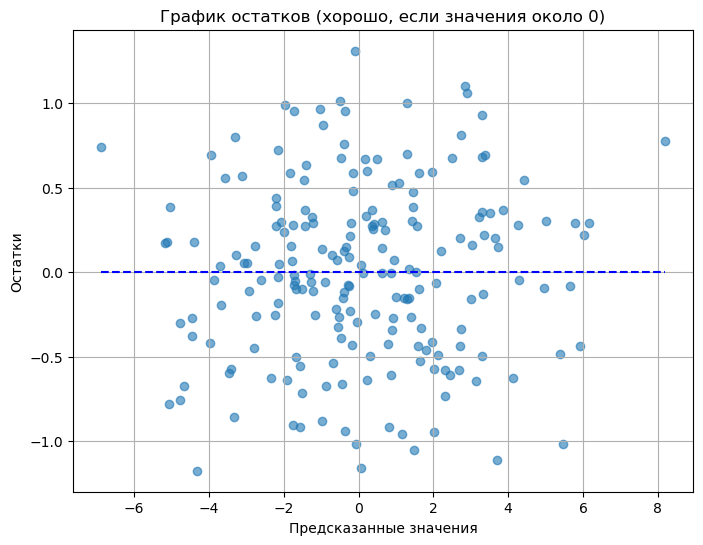

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.hlines(0, y_pred.min(), y_pred.max(), colors='blue', linestyles='dashed')
plt.title("График остатков (хорошо, если значения около 0)")
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.grid(True)
plt.show()

Гистограмма остатков

<Axes: ylabel='Density'>

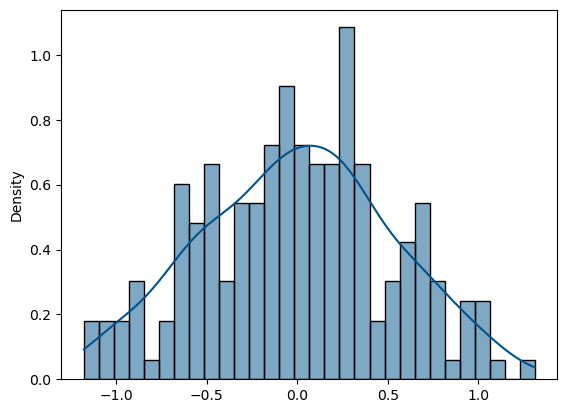

In [32]:
sns.histplot(residuals, kde=True, stat="density", color="#00528d", bins=30, label="Остатки")

Важность признаков

In [33]:
avg_coef = np.mean([est.coef_ for est in model.estimators_], axis=0)

feature_importance = pd.DataFrame({
    "Признаки": feature_names,
    "Коэффициент": avg_coef
})

feature_importance.sort_values(by="Коэффициент", ascending=False)

,Признаки,Коэффициент
4,feature_4,1.043611
6,feature_6,0.353179
2,feature_2,0.102542
0,feature_0,-0.127991
1,feature_1,-0.285704
3,feature_3,-0.328583
8,feature_8,-0.708831
7,feature_7,-1.035962
5,feature_5,-1.096591
9,feature_9,-1.690158


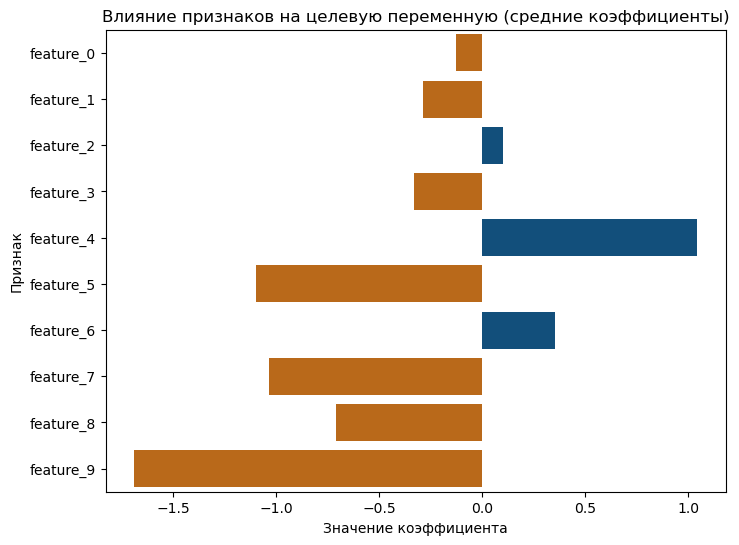

In [34]:
# чтобы не было предупреждения в новых версиях sns
# Создаем колонку для цветового кодирования 
feature_importance["Направление"] = feature_importance["Коэффициент"].apply(
    lambda x: "Положительный" if x > 0 else "Отрицательный"
)

plt.figure(figsize=(8, 6))
# Используем hue с кастомной палитрой в виде словаря
sns.barplot(
    x="Коэффициент", 
    y="Признаки", 
    hue="Направление",
    data=feature_importance, 
    palette={"Положительный": "#00528d", "Отрицательный": "#d36900"},
    legend=False
)
plt.title("Влияние признаков на целевую переменную (средние коэффициенты)")
plt.xlabel("Значение коэффициента")
plt.ylabel("Признак")
plt.show()